In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import pickle

In [45]:
df = pd.read_csv('Psl_Complete_Dataset(2016-2024).csv')

In [46]:
df.head()

,id,match_id,date,season,venue,inning,batting_team,bowling_team,over,ball,...,is_wicket,player_dismissed,dismissal_kind,fielder,winner,win_by,match_type,player_of_match,umpire_1,umpire_2
0,1,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,1,...,True,Mohammad Hafeez,caught,Sharjeel Khan,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
1,2,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,2,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
2,3,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,3,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
3,4,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,4,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza
4,5,1075986,2017-02-09,2017,Dubai International Cricket Stadium,1,Peshawar Zalmi,Islamabad United,1,5,...,False,NaN,NaN,NaN,Islamabad United,wickets 7,regular,BJ Haddin,Ahsan Raza,Shozab Raza


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66112 entries, 0 to 66111
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                66112 non-null  int64 
 1   match_id          66112 non-null  int64 
 2   date              66112 non-null  object
 3   season            66112 non-null  int64 
 4   venue             66112 non-null  object
 5   inning            66112 non-null  int64 
 6   batting_team      66112 non-null  object
 7   bowling_team      66112 non-null  object
 8   over              66112 non-null  int64 
 9   ball              66112 non-null  int64 
 10  batter            66112 non-null  object
 11  bowler            66112 non-null  object
 12  non_striker       66112 non-null  object
 13  batsman_runs      66112 non-null  int64 
 14  extra_runs        66112 non-null  int64 
 15  total_runs        66112 non-null  int64 
 16  extras_type       3561 non-null   object
 17  is_wicket   

In [48]:
df.shape

(66112, 27)

In [49]:
df.describe()

,id,match_id,season,inning,over,ball,batsman_runs,extra_runs,total_runs
count,66112.000000,6.611200e+04,66112.000000,66112.000000,66112.000000,66112.000000,66112.000000,66112.000000,66112.000000
mean,260.512570,1.221449e+06,2020.286468,1.483392,10.141714,3.617392,1.280025,0.069382,1.349407
std,107.596957,1.270599e+05,2.487097,0.502625,5.654251,1.811348,1.652216,0.356554,1.640215
min,1.000000,9.591750e+05,2016.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,182.000000,1.128843e+06,2018.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000
50%,260.000000,1.211672e+06,2020.000000,1.000000,10.000000,4.000000,1.000000,0.000000,1.000000
75%,339.000000,1.293031e+06,2022.000000,2.000000,15.000000,5.000000,1.000000,0.000000,1.000000
max,521.000000,1.416505e+06,2024.000000,4.000000,20.000000,11.000000,6.000000,5.000000,7.000000


In [50]:
df.corr(numeric_only=True)

,id,match_id,season,inning,over,ball,batsman_runs,extra_runs,total_runs,is_wicket
id,1.000000,0.311853,0.396396,0.554430,0.306081,0.020093,0.034966,0.011531,0.037729,0.022506
match_id,0.311853,1.000000,0.989415,0.002664,0.016239,0.008032,0.038826,0.010246,0.041338,-0.001080
season,0.396396,0.989415,1.000000,0.002070,0.017028,0.008455,0.039974,0.010541,0.042558,-0.001976
inning,0.554430,0.002664,0.002070,1.000000,-0.055155,-0.003549,-0.005428,0.003349,-0.004740,0.001772
over,0.306081,0.016239,0.017028,-0.055155,1.000000,0.000039,0.069784,0.011772,0.072854,0.077608
ball,0.020093,0.008032,0.008455,-0.003549,0.000039,1.000000,-0.000924,-0.008150,-0.002702,-0.000162
batsman_runs,0.034966,0.038826,0.039974,-0.005428,0.069784,-0.000924,1.000000,-0.141438,0.976571,-0.179156
extra_runs,0.011531,0.010246,0.010541,0.003349,0.011772,-0.008150,-0.141438,1.000000,0.074910,-0.043574
total_runs,0.037729,0.041338,0.042558,-0.004740,0.072854,-0.002702,0.976571,0.074910,1.000000,-0.189939
is_wicket,0.022506,-0.001080,-0.001976,0.001772,0.077608,-0.000162,-0.179156,-0.043574,-0.189939,1.000000


In [51]:
df.drop(columns = ['umpire_2','umpire_1','player_of_match','fielder','dismissal_kind',
                   'player_dismissed','id','date','extras_type','non_striker'],inplace = True)

In [52]:
df['batting_team'].value_counts()

batting_team
Peshawar Zalmi       12291
Islamabad United     11581
Lahore Qalandars     11158
Karachi Kings        11044
Quetta Gladiators    10743
Multan Sultans        9295
Name: count, dtype: int64

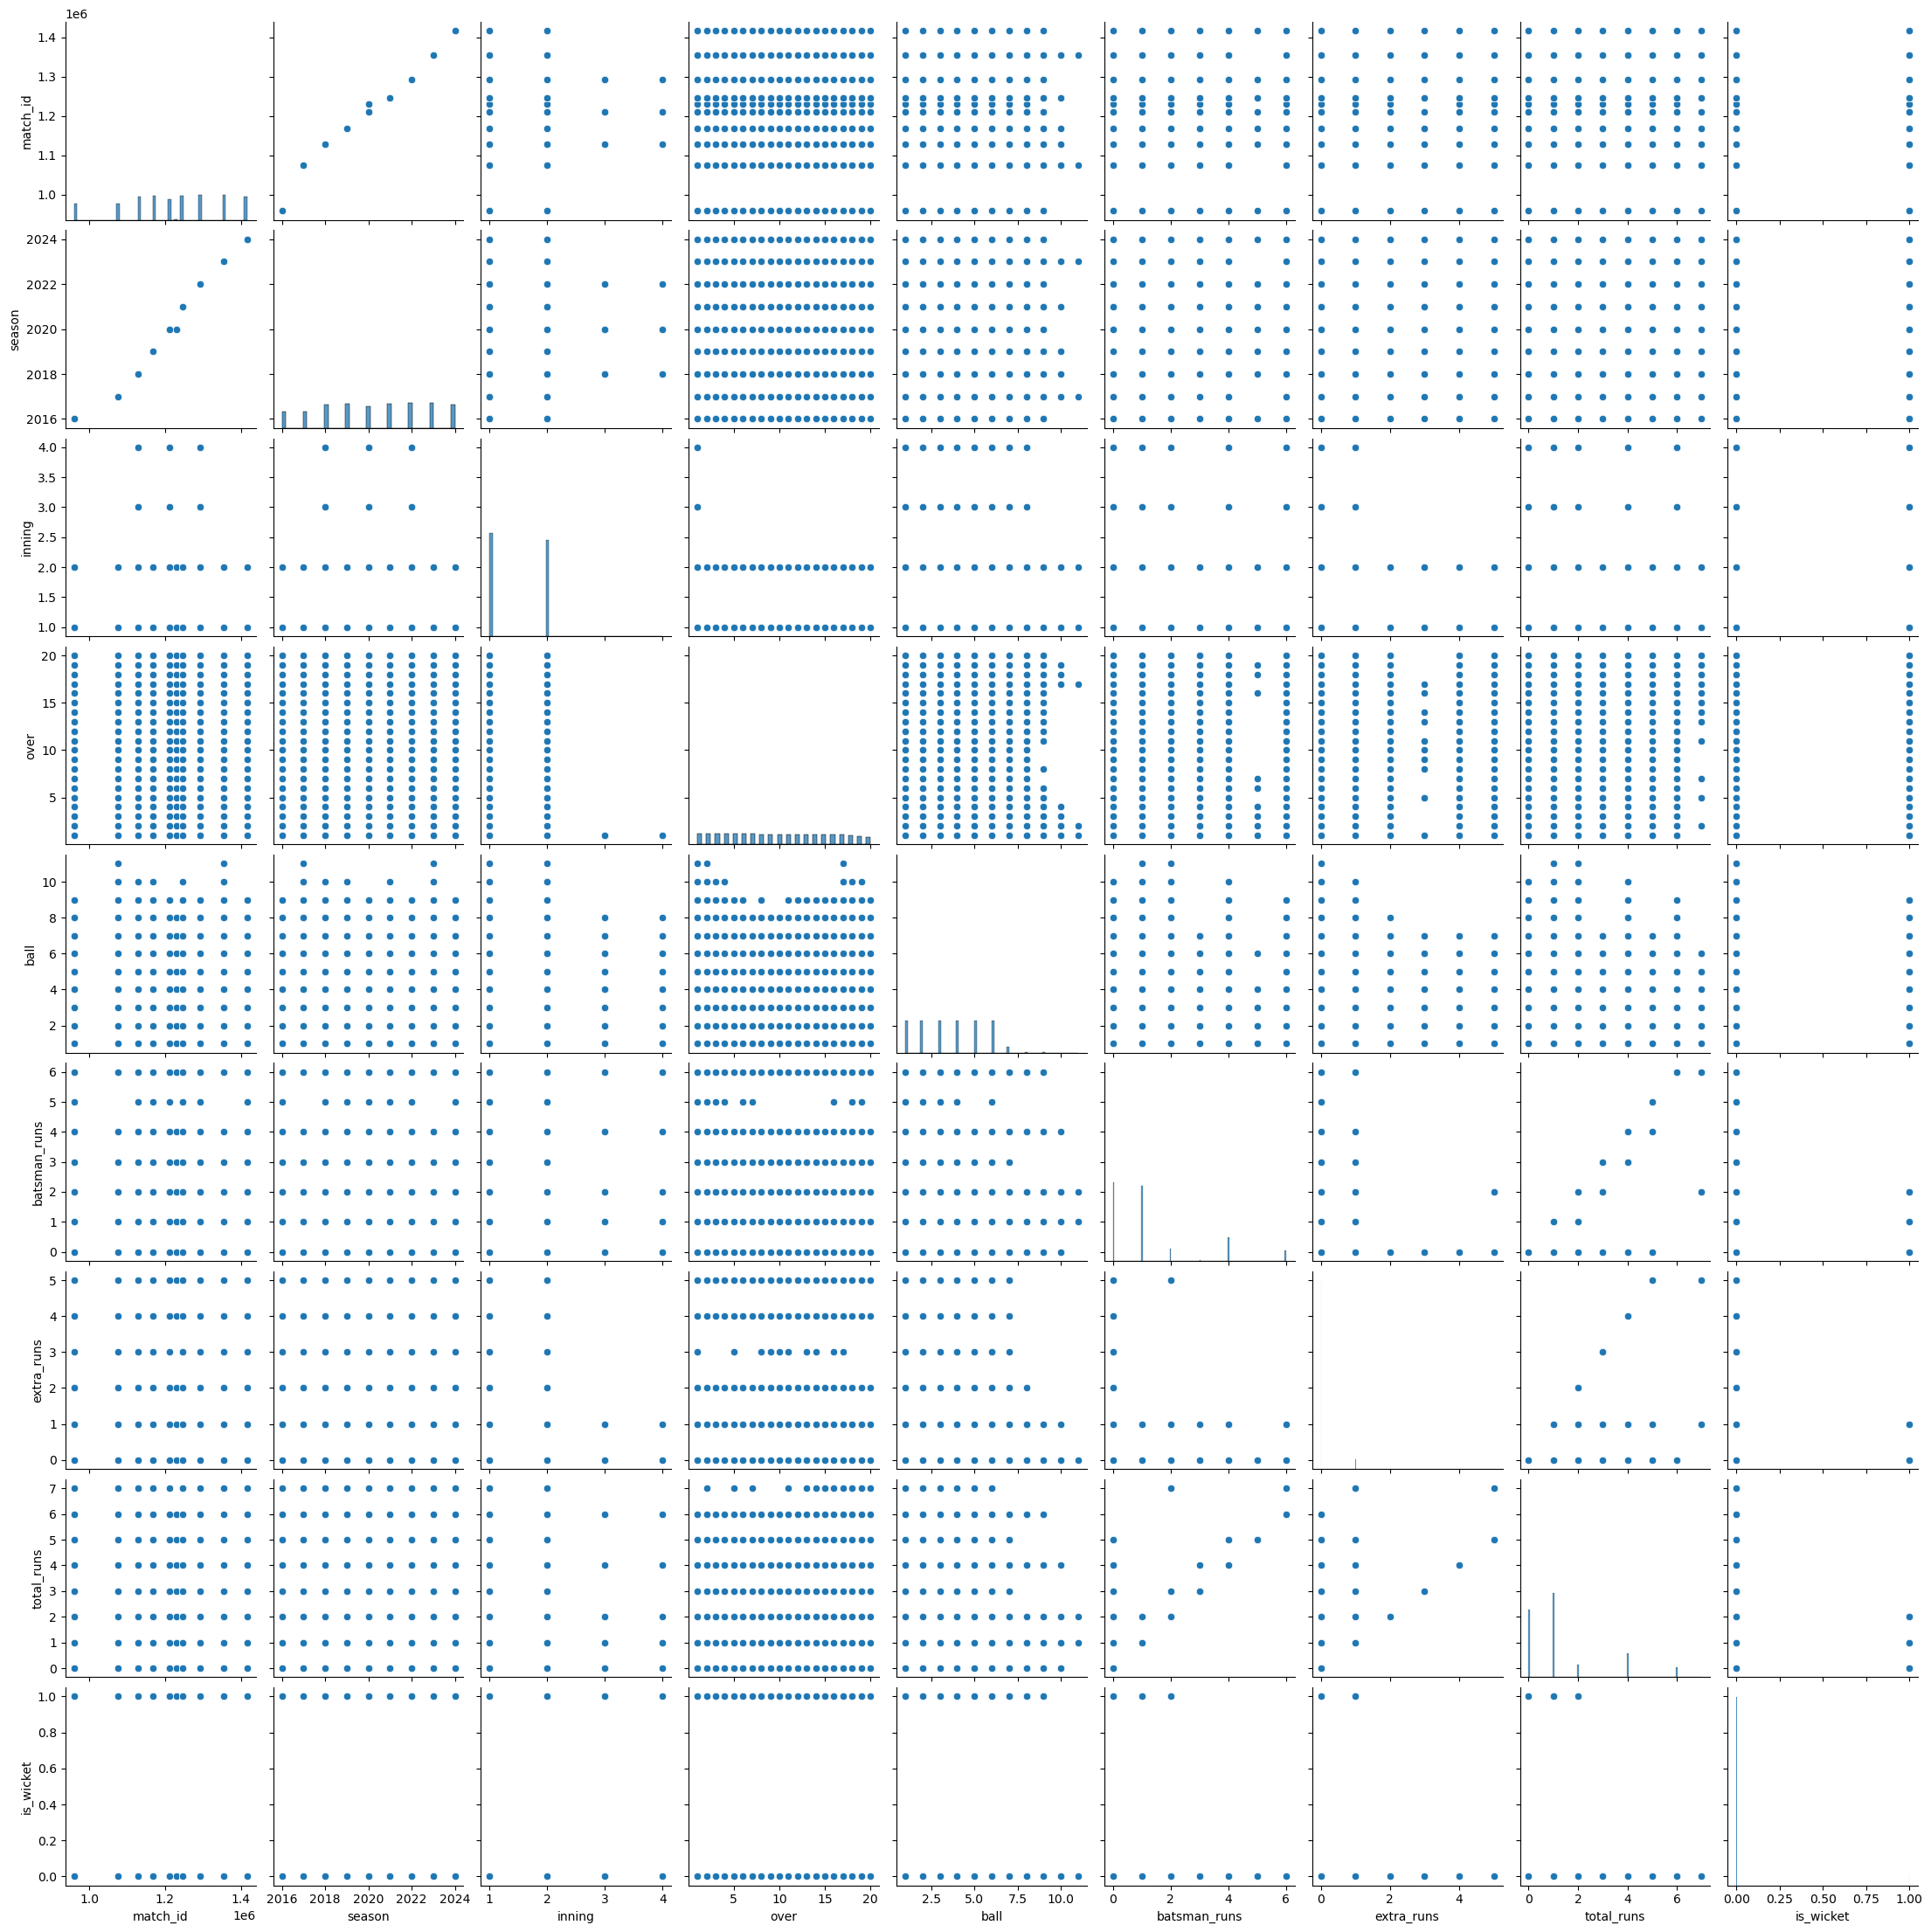

In [53]:
sns.pairplot(df)

In [54]:
df['current_score'] = df.groupby(['match_id','inning'])['total_runs'].cumsum()

In [55]:
df['total_out'] = df.groupby(['match_id','inning'])['is_wicket'].cumsum()

In [56]:
df.drop(columns = ['season','batter','bowler','batsman_runs','extra_runs','total_runs','winner','win_by','match_type'],
       inplace = True)

In [57]:
df = df[df['inning'] == 1]

In [58]:
df1 = df.copy()

In [59]:
df1.drop(columns = ['inning'], inplace = True)

In [60]:
df1.drop(columns = ['is_wicket'], inplace = True)

In [61]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34227 entries, 0 to 65999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   match_id       34227 non-null  int64 
 1   venue          34227 non-null  object
 2   batting_team   34227 non-null  object
 3   bowling_team   34227 non-null  object
 4   over           34227 non-null  int64 
 5   ball           34227 non-null  int64 
 6   current_score  34227 non-null  int64 
 7   total_out      34227 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 2.4+ MB


In [62]:
groups = df1.groupby('match_id')

In [63]:
df1['balls_remaining'] = 120 - ((df['over']-1)*6 + df['ball'])

In [64]:
df1.columns

Index(['match_id', 'venue', 'batting_team', 'bowling_team', 'over', 'ball',
       'current_score', 'total_out', 'balls_remaining'],
      dtype='object')

In [65]:
df1['wickets_remaining'] = 10 - df1['total_out']

In [66]:
df1['crr'] = df1['current_score']/(120 - df1['balls_remaining'])*6

In [67]:
target = df1.groupby(['match_id'])['current_score'].max()
df1['target'] = df1['match_id'].map(target)

In [68]:
df1.drop(columns = ['match_id','over','ball','total_out'], inplace = True)

In [69]:
df1['venue'] = df1['venue'].str.split(' ').str[0]

In [70]:
df1.columns

Index(['venue', 'batting_team', 'bowling_team', 'current_score',
       'balls_remaining', 'wickets_remaining', 'crr', 'target'],
      dtype='object')

In [71]:
X = df1.drop(columns = ['target'])
y = df1['target']

In [72]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [73]:
X_train.shape

(27381, 7)

In [74]:
X_train.columns

Index(['venue', 'batting_team', 'bowling_team', 'current_score',
       'balls_remaining', 'wickets_remaining', 'crr'],
      dtype='object')

In [75]:
trf1 = ColumnTransformer([
    ('ohe', OneHotEncoder(drop='first'), ['venue', 'batting_team', 'bowling_team']),
    ('scale', StandardScaler(), ['balls_remaining','current_score','wickets_remaining','crr'])
])

In [76]:
trf1.fit(X_train)

,transformers,"[('ohe', ...), ('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [77]:
pipe = Pipeline([
    ('trf', trf1),
    ('model',XGBRegressor(
        n_estimators = 2000,
        learning_rate = 0.1,
        max_depth = 10,
        random_state=42,
        eval_metric = 'mae',
        early_stopping_rounds = 50
        ) )
])

In [78]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [79]:
X_val_trans = trf1.transform(X_val)

In [80]:
pipe.fit(X_train_final,y_train_final,
        model__eval_set=[(X_val_trans, y_val)],
        model__verbose = 100)

[0]	validation_0-mae:23.58563
[100]	validation_0-mae:10.39955
[200]	validation_0-mae:10.11645
[300]	validation_0-mae:10.03505
[400]	validation_0-mae:9.99110
[500]	validation_0-mae:9.96583
[600]	validation_0-mae:9.94724
[700]	validation_0-mae:9.93827
[800]	validation_0-mae:9.93315
[874]	validation_0-mae:9.93244


,steps,"[('trf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [81]:
y_pred = pipe.predict(X_test)

In [82]:
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))

0.9226599335670471
4.4953179359436035


In [83]:
df['venue'].unique()

array(['Dubai International Cricket Stadium', 'Sharjah Cricket Stadium',
       'Gaddafi Stadium', 'National Stadium', 'Sheikh Zayed Stadium',
       'Multan Cricket Stadium', 'Rawalpindi Cricket Stadium',
       'National Stadium, Karachi', 'Sheikh Zayed Stadium, Abu Dhabi',
       'Gaddafi Stadium, Lahore'], dtype=object)

In [84]:
df['batting_team'].unique()

array(['Peshawar Zalmi', 'Quetta Gladiators', 'Karachi Kings',
       'Islamabad United', 'Lahore Qalandars', 'Multan Sultans'],
      dtype=object)

In [85]:
score = 145
over = 16
balls = 0
total_out = 5
wickets_remaining = 10 - total_out
remaining_balls = 120 - (over*6) + balls
current_rr = score/(120 - remaining_balls)*6
#last_five_overs = 44
#last_two_overs_wkt = 2

In [86]:
input_ = pd.DataFrame(
    {'venue':['Rawalpindi'],'batting_team':['Multan Sultans'], 'bowling_team':['Quetta Gladiators'],
    'balls_remaining': remaining_balls, 'current_score': score, 'wickets_remaining':wickets_remaining,
     'crr':current_rr}
)

In [87]:
input_

,venue,batting_team,bowling_team,balls_remaining,current_score,wickets_remaining,crr
0,Rawalpindi,Multan Sultans,Quetta Gladiators,24,145,5,9.0625


In [88]:
pipe.predict(input_)

array([199.86319], dtype=float32)

In [1299]:
with open("psl_pipeline2.pkl","wb") as f:
    pickle.dump(pipe, f)